### Libraries 

In [1]:
import sys
sys.path.append(r'C:\Users\User\005_Libraries')

import mylibs

In [10]:
from collections import Counter
from datetime import datetime

### Sentiment Analysis

In [2]:
df_analyzed= pd.read_csv('002_Data/gaming_tweets_analyzed_20260110_122738.csv')
df_analyzed

,tweet_id,text,created_at,author_id,retweet_count,reply_count,like_count,quote_count,sentiment,sentiment_score,primary_topic,topics,games,companies,platforms,people,content_type,summary,analyzed_at
0,2001656770645615013,@Lexar_Gaming I need one @jonanarranzz,2025-12-18 14:12:17+00:00,1514991564174635012,0,0,0,0,positive,0.70,product request,"['gaming hardware', 'product desire', 'social ...",[],['Lexar Gaming'],[],['jonanarranzz'],other,User expresses need for a Lexar Gaming product...,2026-01-10 11:35:17.635985
1,2001656753029550085,Cleared the bs reposts off my profile. Kept th...,2025-12-18 14:12:13+00:00,1880073685794447360,0,0,0,0,neutral,0.60,profile cleanup,"['social media management', 'content curation'...",[],[],[],[],other,User cleaned their social media profile by rem...,2026-01-10 11:35:21.558546
2,2001656732943040516,@OBE1plays That would be all of my favourite g...,2025-12-18 14:12:08+00:00,1122515293870231553,0,0,0,0,positive,0.90,gaming preferences,"['gaming companies', 'favorite games', 'brand ...",[],"['Nintendo', 'Square Enix']",[],['OBE1plays'],discussion,User expresses strong preference for Nintendo ...,2026-01-10 11:35:25.692536
3,2001656725246521571,The most dangerous player in efootball \n#eFoo...,2025-12-18 14:12:06+00:00,1491794006031802368,0,0,0,0,positive,0.70,eFootball gameplay,"['eFootball skills', 'player performance', 'fo...","['eFootball', 'EA FC', 'UFL']",[],['PS5'],[],excitement,Player boasting about being the most dangerous...,2026-01-10 11:35:30.150225
4,2001656700269445349,@CommodoreBlog This was peak C64 gaming.,2025-12-18 14:12:00+00:00,19237341,0,0,0,0,positive,0.80,retro gaming,"['retro gaming', 'C64', 'nostalgia']",[],['Commodore'],['C64'],[],discussion,User expresses nostalgia about Commodore 64 ga...,2026-01-10 11:35:33.981522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2001655584056316400,@0xCrocy @Kindred_AI kindred ai turning solo g...,2025-12-18 14:07:34+00:00,1097806680375492609,0,0,1,0,positive,0.80,AI gaming companion,"['AI gaming', 'multiplayer experience', 'gamin...",[],['Kindred_AI'],[],['0xCrocy'],excitement,User expresses enthusiasm about Kindred AI's a...,2026-01-10 11:41:58.460309
96,2001655577785893171,DM now for 2D/3D Vtuber Model!\n\nNow availabl...,2025-12-18 14:07:33+00:00,1887980906914398209,0,0,0,0,positive,0.70,VTuber Services,"['vtuber model creation', 'streaming services'...",[],[],['Twitch'],[],other,User is advertising their services for creatin...,2026-01-10 11:42:02.927867
97,2001655571490213979,@Arlo140f3qz Useful gaming guide.,2025-12-18 14:07:31+00:00,1786799937935589377,0,0,0,0,positive,0.70,gaming guide,"['gaming guide', 'recommendation', 'utility']",[],[],[],['Arlo140f3qz'],review,User positively acknowledges a gaming guide as...,2026-01-10 11:42:06.557912
98,2001655556130705499,"In-game assets are meant to be used, not flipp...",2025-12-18 14:07:28+00:00,342153773,0,0,0,0,positive,0.75,Web3 gaming,"['Web3 gaming', 'NFT marketplace', 'game econo...",[],"['Immutable', 'GBMauction']",['Immutable'],[],discussion,User advocates for GBM Auction House on Immuta...,2026-01-10 11:42:10.907881


In [3]:
sentiment_counts= df_analyzed['sentiment'].value_counts()

for sentiment, count in sentiment_counts.items():
    percentage= (count / len(df_analyzed)) * 100
    print(f"{sentiment.capitalize():10s}: {count:3d} tweets ({percentage:5.1f}%)")

Positive  :  61 tweets ( 61.0%)
Neutral   :  25 tweets ( 25.0%)
Negative  :  14 tweets ( 14.0%)


In [4]:
avg_sentiment= df_analyzed['sentiment_score'].mean()

print(f"\nAverage Sentiment Score: {avg_sentiment:.2f}")


Average Sentiment Score: 0.64


In [5]:
most_positive= df_analyzed.loc[df_analyzed['sentiment_score'].idxmax()]

print(f"Score: {most_positive['sentiment_score']:.2f}")
print(f"Text: {most_positive['text'][:100]}...")

Score: 0.90
Text: @OBE1plays That would be all of my favourite gaming under one roof.

Nintendo and Square Enix, for m...


In [6]:
most_negative= df_analyzed.loc[df_analyzed['sentiment_score'].idxmin()]

print(f"Score: {most_negative['sentiment_score']:.2f}")
print(f"Text: {most_negative['text'][:100]}...")

Score: 0.10
Text: @NVIDIAGeForce backing out if graphics cards for consumers is this biggest slap in the face, ever. T...


### Topics Analysis

In [7]:
top_topics= df_analyzed['primary_topic'].value_counts().head(10)

for i, (topic, count) in enumerate(top_topics.items(), 1):
    print(f"{i:2d}. {topic:30s} ({count:2d} tweets)")

    1. blockchain gaming              ( 6 tweets)
    2. crypto trading                 ( 4 tweets)
    3. game promotion                 ( 3 tweets)
    4. AI gaming                      ( 2 tweets)
    5. Web3 gaming                    ( 2 tweets)
    6. game difficulty                ( 2 tweets)
    7. product contest                ( 1 tweets)
    8. community networking           ( 1 tweets)
    9. device promotion               ( 1 tweets)
   10. trade show                     ( 1 tweets)


In [8]:
content_types= df_analyzed['content_type'].value_counts()

for content_type, count in content_types.items():
    percentage= (count / len(df_analyzed)) * 100
    print(f"{content_type.capitalize():12s}: {count:3d} tweets ({percentage:5.1f}%)")

Discussion  :  30 tweets ( 30.0%)
Excitement  :  26 tweets ( 26.0%)
Other       :  16 tweets ( 16.0%)
Complaint   :  12 tweets ( 12.0%)
News        :  12 tweets ( 12.0%)
Question    :   3 tweets (  3.0%)
Review      :   1 tweets (  1.0%)


### Entities Analysis (Games, Companies, Platforms)

In [11]:
all_games= []

for games_str in df_analyzed['games']:
    try:
        games= eval(games_str)
        all_games.extend(games)
    except:
        pass

if all_games:
    game_counts= Counter(all_games)
    print(f"\nMost Mentioned Games (found {len(game_counts)} unique games):")
    for i, (game, count) in enumerate(game_counts.most_common(10), 1):
        print(f"{i:2d}. {game:30s} ({count:2d} mentions)")
else:
    print("\nMost Mentioned Games: No games detected")


Most Mentioned Games (found 38 unique games):
 1. GTA 6                          ( 3 mentions)
 2. GTA 5                          ( 2 mentions)
 3. Genshin Impact                 ( 2 mentions)
 4. eFootball                      ( 1 mentions)
 5. EA FC                          ( 1 mentions)
 6. UFL                            ( 1 mentions)
 7. GTA Online                     ( 1 mentions)
 8. Elden Ring                     ( 1 mentions)
 9. Zelda                          ( 1 mentions)
10. Resident Evil                  ( 1 mentions)


In [12]:
all_companies= []
for companies_str in df_analyzed['companies']:
    try:
        companies= eval(companies_str)
        all_companies.extend(companies)
    except:
        pass

if all_companies:
    company_counts= Counter(all_companies)
    print(f"\nMost Mentioned Companies (found {len(company_counts)} unique companies):")
    for i, (company, count) in enumerate(company_counts.most_common(10), 1):
        print(f"   {i:2d}. {company:30s} ({count:2d} mentions)")
else:
    print("\nMost Mentioned Companies: No companies detected")


Most Mentioned Companies (found 53 unique companies):
    1. LEGAS                          ( 4 mentions)
    2. NVIDIA                         ( 4 mentions)
    3. Nintendo                       ( 3 mentions)
    4. OnePlus                        ( 3 mentions)
    5. Amazon                         ( 2 mentions)
    6. YOM_Official                   ( 2 mentions)
    7. Xbox                           ( 2 mentions)
    8. FromSoftware                   ( 2 mentions)
    9. Lexar Gaming                   ( 1 mentions)
   10. Square Enix                    ( 1 mentions)


In [13]:
all_platforms= []
for platforms_str in df_analyzed['platforms']:
    try:
        platforms= eval(platforms_str)
        all_platforms.extend(platforms)
    except:
        pass

if all_platforms:
    platform_counts= Counter(all_platforms)
    print(f"\nMost Mentioned Platforms (found {len(platform_counts)} unique platforms):")
    for i, (platform, count) in enumerate(platform_counts.most_common(10), 1):
        print(f"   {i:2d}. {platform:30s} ({count:2d} mentions)")
else:
    print("\nMost Mentioned Platforms: No platforms detected")


Most Mentioned Platforms (found 35 unique platforms):
    1. Twitter                        ( 5 mentions)
    2. PC                             ( 5 mentions)
    3. PS5                            ( 4 mentions)
    4. YouTube                        ( 4 mentions)
    5. Twitch                         ( 2 mentions)
    6. DePIN                          ( 2 mentions)
    7. C64                            ( 1 mentions)
    8. 8 bit                          ( 1 mentions)
    9. Solana                         ( 1 mentions)
   10. mobile                         ( 1 mentions)


### Summary Statistics

In [14]:
print("\nTweet Engagement:")
print(f"Total Retweets:  {df_analyzed['retweet_count'].sum():,}")
print(f"Total Replies:   {df_analyzed['reply_count'].sum():,}")
print(f"Total Likes:     {df_analyzed['like_count'].sum():,}")
print(f"Total Quotes:    {df_analyzed['quote_count'].sum():,}")

print("\nAverage Engagement per Tweet:")
print(f"Avg Retweets:    {df_analyzed['retweet_count'].mean():.2f}")
print(f"Avg Replies:     {df_analyzed['reply_count'].mean():.2f}")
print(f"Avg Likes:       {df_analyzed['like_count'].mean():.2f}")
print(f"Avg Quotes:      {df_analyzed['quote_count'].mean():.2f}")

print("\nSentiment vs Engagement:")
for sentiment in df_analyzed['sentiment'].unique():
    sentiment_tweets= df_analyzed[df_analyzed['sentiment']== sentiment]
    avg_likes= sentiment_tweets['like_count'].mean()
    print(f"{sentiment.capitalize():10s} tweets: {avg_likes:.2f} avg likes")


Tweet Engagement:
Total Retweets:  2
Total Replies:   10
Total Likes:     16
Total Quotes:    0

Average Engagement per Tweet:
Avg Retweets:    0.02
Avg Replies:     0.10
Avg Likes:       0.16
Avg Quotes:      0.00

Sentiment vs Engagement:
Positive   tweets: 0.20 avg likes
Neutral    tweets: 0.04 avg likes
Negative   tweets: 0.21 avg likes


### Visualization Dashboard

Dashboard saved as: 002_Data/gaming_tweets_dashboard_20260112_141740.png


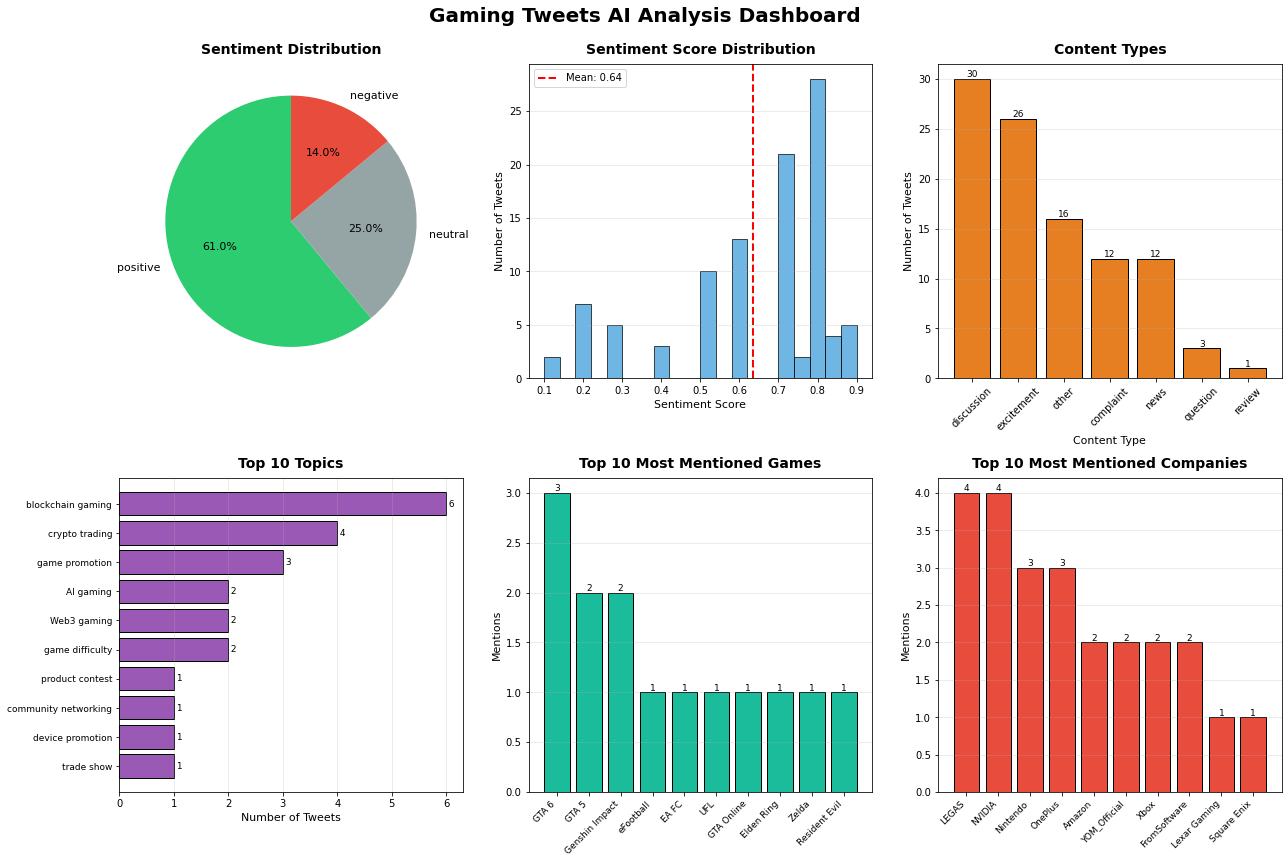

In [28]:
# Visualization dashboard
fig, axes= plt.subplots(2, 3, figsize= (18, 12))
fig.suptitle('Gaming Tweets AI Analysis Dashboard', fontsize= 20, fontweight= 'bold', y= 0.995)

# === 1. Sentiment Distribution (Pie Chart) ===
sentiment_counts= df_analyzed['sentiment'].value_counts()
colors= ['#2ecc71', '#95a5a6', '#e74c3c']
axes[0, 0].pie(sentiment_counts, labels= sentiment_counts.index, autopct= '%1.1f%%', 
               startangle= 90, colors= colors, textprops= {'fontsize': 11})
axes[0, 0].set_title('Sentiment Distribution', fontsize= 14, fontweight= 'bold', pad= 10)

# === 2. Sentiment Scores (Histogram) ===
axes[0, 1].hist(df_analyzed['sentiment_score'], bins= 20, color= '#3498db', edgecolor= 'black', alpha= 0.7)
axes[0, 1].axvline(df_analyzed['sentiment_score'].mean(), color= 'red', linestyle= '--', 
                   linewidth= 2, label= f'Mean: {df_analyzed["sentiment_score"].mean():.2f}')
axes[0, 1].set_xlabel('Sentiment Score', fontsize= 11)
axes[0, 1].set_ylabel('Number of Tweets', fontsize= 11)
axes[0, 1].set_title('Sentiment Score Distribution', fontsize= 14, fontweight= 'bold', pad= 10)
axes[0, 1].legend()
axes[0, 1].grid(axis= 'y', alpha= 0.3)

# === 3. Content Types (Bar Chart) ===
content_counts= df_analyzed['content_type'].value_counts()
bars= axes[0, 2].bar(content_counts.index, content_counts.values, color= '#e67e22', edgecolor= 'black')
axes[0, 2].set_xlabel('Content Type', fontsize= 11)
axes[0, 2].set_ylabel('Number of Tweets', fontsize= 11)
axes[0, 2].set_title('Content Types', fontsize= 14, fontweight= 'bold', pad= 10)
axes[0, 2].tick_params(axis= 'x', rotation= 45)

for bar in bars:
    height= bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha= 'center', va= 'bottom', fontsize= 9)
axes[0, 2].grid(axis= 'y', alpha= 0.3)

# === 4. Top 10 Topics (Horizontal Bar) ===
top_topics= df_analyzed['primary_topic'].value_counts().head(10)
bars= axes[1, 0].barh(range(len(top_topics)), top_topics.values, color= '#9b59b6', edgecolor= 'black')
axes[1, 0].set_yticks(range(len(top_topics)))
axes[1, 0].set_yticklabels(top_topics.index, fontsize= 9)
axes[1, 0].set_xlabel('Number of Tweets', fontsize= 11)
axes[1, 0].set_title('Top 10 Topics', fontsize= 14, fontweight= 'bold', pad= 10)
axes[1, 0].invert_yaxis()

for i, (bar, value) in enumerate(zip(bars, top_topics.values)):
    axes[1, 0].text(value, i, f' {value}', va= 'center', fontsize= 9)
axes[1, 0].grid(axis= 'x', alpha= 0.3)

# === 5. Top Games (Bar Chart) ===
all_games= []
for games_str in df_analyzed['games']:
    try:
        games= eval(games_str)
        all_games.extend(games)
    except:
        pass

if all_games:
    game_counts= Counter(all_games)
    top_games= dict(game_counts.most_common(10))
    bars= axes[1, 1].bar(range(len(top_games)), top_games.values(), color= '#1abc9c', edgecolor= 'black')
    axes[1, 1].set_xticks(range(len(top_games)))
    axes[1, 1].set_xticklabels(top_games.keys(), rotation= 45, ha= 'right', fontsize= 9)
    axes[1, 1].set_ylabel('Mentions', fontsize= 11)
    axes[1, 1].set_title('Top 10 Most Mentioned Games', fontsize= 14, fontweight= 'bold', pad= 10)
    
    for bar in bars:
        height= bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha= 'center', va= 'bottom', fontsize= 9)
    axes[1, 1].grid(axis= 'y', alpha= 0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No games detected', ha= 'center', va= 'center', fontsize= 12)
    axes[1, 1].set_title('Top Games', fontsize= 14, fontweight= 'bold')

# === 6. Top Companies (Bar Chart) ===
all_companies= []
for companies_str in df_analyzed['companies']:
    try:
        companies= eval(companies_str)
        all_companies.extend(companies)
    except:
        pass

if all_companies:
    company_counts= Counter(all_companies)
    top_companies= dict(company_counts.most_common(10))
    bars= axes[1, 2].bar(range(len(top_companies)), top_companies.values(), color= '#e74c3c', edgecolor= 'black')
    axes[1, 2].set_xticks(range(len(top_companies)))
    axes[1, 2].set_xticklabels(top_companies.keys(), rotation= 45, ha= 'right', fontsize= 9)
    axes[1, 2].set_ylabel('Mentions', fontsize= 11)
    axes[1, 2].set_title('Top 10 Most Mentioned Companies', fontsize= 14, fontweight= 'bold', pad= 10)
    
    for bar in bars:
        height= bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha= 'center', va= 'bottom', fontsize= 9)
    axes[1, 2].grid(axis= 'y', alpha= 0.3)
else:
    axes[1, 2].text(0.5, 0.5, 'No companies detected', ha= 'center', va= 'center', fontsize= 12)
    axes[1, 2].set_title('Top Companies', fontsize= 14, fontweight= 'bold')

plt.tight_layout()

timestamp= datetime.now().strftime('%Y%m%d_%H%M%S')
filename= f'002_Data/gaming_tweets_dashboard_{timestamp}.png'
plt.savefig(filename, dpi= 300, bbox_inches= 'tight', facecolor= 'white')

print(f"Dashboard saved as: {filename}")
plt.show()

Engagement chart saved as: 002_Data/sentiment_engagement_20260112_141740.png


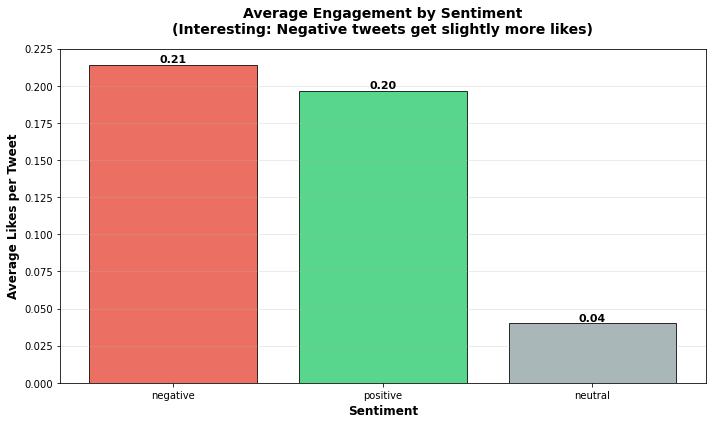

In [30]:
# Sentiment vs Engagement
fig, ax= plt.subplots(figsize= (10, 6))

sentiment_engagement= df_analyzed.groupby('sentiment')['like_count'].mean().sort_values(ascending= False)

colors_map= {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
colors= [colors_map.get(sent, '#3498db') for sent in sentiment_engagement.index]

bars= ax.bar(sentiment_engagement.index, sentiment_engagement.values, color= colors, edgecolor= 'black', alpha= 0.8)

ax.set_xlabel('Sentiment', fontsize= 12, fontweight= 'bold')
ax.set_ylabel('Average Likes per Tweet', fontsize= 12, fontweight= 'bold')
ax.set_title('Average Engagement by Sentiment\n(Interesting: Negative tweets get slightly more likes)', 
             fontsize= 14, fontweight= 'bold', pad= 15)
ax.grid(axis= 'y', alpha= 0.3)

for bar in bars:
    height= bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha= 'center', va= 'bottom', fontsize= 11, fontweight= 'bold')

plt.tight_layout()

filename2= f'002_Data/sentiment_engagement_{timestamp}.png'
plt.savefig(filename2, dpi= 300, bbox_inches= 'tight', facecolor= 'white')
print(f"Engagement chart saved as: {filename2}")
plt.show()

In [31]:
print(f"\nAnalysis Summary:")
print(f"Total tweets analyzed: {len(df_analyzed)}")
print(f"Overall sentiment: {'Positive' if avg_sentiment > 0.6 else 'Neutral' if avg_sentiment > 0.4 else 'Negative'}")
print(f"Average sentiment score: {avg_sentiment:.2f}/1.00")
print(f"Unique games detected: {len(game_counts)}")
print(f"Unique companies detected: {len(company_counts)}")
print(f"Unique platforms detected: {len(platform_counts)}")

print(f"\nKey Insights:")
print(f"Most discussed topic: {top_topics.index[0]}")
print(f"Most mentioned game: {list(game_counts.most_common(1)[0])[0] if game_counts else 'N/A'}")
print(f"Most mentioned company: {list(company_counts.most_common(1)[0])[0] if company_counts else 'N/A'}")
print(f"Dominant content type: {content_counts.index[0]}")

print(f"\nFiles created:")
print(f"Dashboard: gaming_tweets_dashboard_{timestamp}.png")
print(f"Engagement chart: sentiment_engagement_{timestamp}.png")


Analysis Summary:
Total tweets analyzed: 100
Overall sentiment: Positive
Average sentiment score: 0.64/1.00
Unique games detected: 38
Unique companies detected: 53
Unique platforms detected: 35

Key Insights:
Most discussed topic: blockchain gaming
Most mentioned game: GTA 6
Most mentioned company: LEGAS
Dominant content type: discussion

Files created:
Dashboard: gaming_tweets_dashboard_20260112_141740.png
Engagement chart: sentiment_engagement_20260112_141740.png
